# Regression from Scratch (NumPy only) — Income

**Role:** primary deliverable. Pure-NumPy MLP — no torch/tensorflow. `sklearn` ONLY for split/scaler/metrics.

**Parity promise:** same data, same 13 features, same architecture `Linear(13→32)→ReLU→Linear(32→1)`, same He init family, same Adam(1e-3), same 80/20 split + scalers, same seed 42 as `regression_pytorch.ipynb` (the oracle).

**Target handling (same as oracle):** model trains on z-scored `Income` (train-fit scaler) and inverse-transforms for metrics in raw $. Raw $ (~50k scale) would explode gradients under lr=1e-3.

Pipeline: Load Data → Dataset Class (NumPy) → Batches → Model Class → Training Loop (hand backprop) → Inference Loop. Weights saved to `./weights/regression_scratch.npz`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
os.makedirs("weights", exist_ok=True)

# ---- 1. LOAD DATA (identical cleaning to oracle) ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
df = df.dropna(subset=["Income"]).copy()
print("cleaned:", df.shape, "| Income median:", round(df["Income"].median()))

REG_FEATURES = [
    "NumCatalogPurchases", "MntMeatProducts", "MntWines", "NumWebVisitsMonth",
    "MntSweetProducts", "MntFruits", "NumWebPurchases", "MntGoldProds",
    "NumStorePurchases", "MntFishProducts", "Kidhome", "Age", "NumDealsPurchases",
]
X_full = df[REG_FEATURES].values
y_full = df["Income"].astype(float).values
print(f"features: {len(REG_FEATURES)} dims (all numeric)")

cleaned: (2213, 28) | Income median: 51373
features: 13 dims (all numeric)


## 2–3. Dataset Class + batches (NumPy stand-in for DataLoader; y standardized)

In [2]:
class NumpyDataset:
    """Mirrors torch Dataset API: len/getitem over float64 NumPy arrays."""
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def batch_generator(ds, batch_size=64, shuffle=True, rng=None):
    idx = np.arange(len(ds))
    if shuffle:
        idx = rng.permutation(idx)
    for s in range(0, len(ds), batch_size):
        b = idx[s:s + batch_size]
        yield ds.X[b], ds.y[b]

X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED)
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
y_scaler = StandardScaler().fit(y_temp.reshape(-1, 1))
ytr_z = y_scaler.transform(y_temp.reshape(-1, 1)).ravel()
yte_z = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
Y_MEAN, Y_SCALE = float(y_scaler.mean_[0]), float(y_scaler.scale_[0])
print(f"train {Xtr.shape} test {Xte.shape} | y mean {y_full.mean():.0f} std {y_full.std():.0f}")
print(f"y scaler: mean {Y_MEAN:.0f} scale {Y_SCALE:.0f} (train on z, report in $)")
train_ds, test_ds = NumpyDataset(Xtr, ytr_z), NumpyDataset(Xte, yte_z)

def z_to_raw(z):
    return np.asarray(z).ravel() * Y_SCALE + Y_MEAN

train (1770, 13) test (443, 13) | y mean 52237 std 25173
y scaler: mean 52026 scale 26009 (train on z, report in $)


## 4. Model Class — `Linear(13→32)→ReLU→Linear(32→1)`, He init

In [3]:
class ScratchMLP:
    def __init__(self, in_dim=13, h=32, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((in_dim, h)) * np.sqrt(2.0 / in_dim)  # He
        self.b1 = np.zeros(h)
        self.W2 = rng.standard_normal((h, 1)) * np.sqrt(2.0 / h)
        self.b2 = np.zeros(1)
        self.mW1 = np.zeros_like(self.W1); self.vW1 = np.zeros_like(self.W1)
        self.mb1 = np.zeros_like(self.b1); self.vb1 = np.zeros_like(self.b1)
        self.mW2 = np.zeros_like(self.W2); self.vW2 = np.zeros_like(self.W2)
        self.mb2 = np.zeros_like(self.b2); self.vb2 = np.zeros_like(self.b2)
        self.t = 0
    def forward(self, X):
        Z1 = X @ self.W1 + self.b1
        A1 = np.maximum(0, Z1)  # ReLU
        pred = A1 @ self.W2 + self.b2
        return Z1, A1, pred
    def predict(self, X):
        return self.forward(X)[2].ravel()
    def adam_step(self, grads, lr=1e-3, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for name in ("W1", "b1", "W2", "b2"):
            g = grads[name]
            m = getattr(self, "m" + name); v = getattr(self, "v" + name)
            m[:] = b1 * m + (1 - b1) * g
            v[:] = b2 * v + (1 - b2) * g * g
            mhat = m / (1 - b1 ** self.t); vhat = v / (1 - b2 ** self.t)
            getattr(self, name).__isub__(lr * mhat / (np.sqrt(vhat) + eps))

model = ScratchMLP(in_dim=len(REG_FEATURES), h=32, seed=SEED)
n_params = model.W1.size + model.b1.size + model.W2.size + model.b2.size
print(f"params: {n_params} (expect 481)")

params: 481 (expect 481)


## 5. Training Loop — hand forward + MSE backprop (z-space) + Adam (50 epochs)

epoch 01 | train_MSE_z 0.8914 | val_MSE_z 0.4145 | val_RMSE_$ 16746
epoch 10 | train_MSE_z 0.5191 | val_MSE_z 0.2237 | val_RMSE_$ 12301
epoch 20 | train_MSE_z 0.4867 | val_MSE_z 0.1944 | val_RMSE_$ 11466
epoch 30 | train_MSE_z 0.4729 | val_MSE_z 0.1787 | val_RMSE_$ 10996
epoch 40 | train_MSE_z 0.4637 | val_MSE_z 0.1796 | val_RMSE_$ 11022
epoch 50 | train_MSE_z 0.4562 | val_MSE_z 0.1682 | val_RMSE_$ 10666
saved: weights/regression_scratch.npz + scratch_history.csv


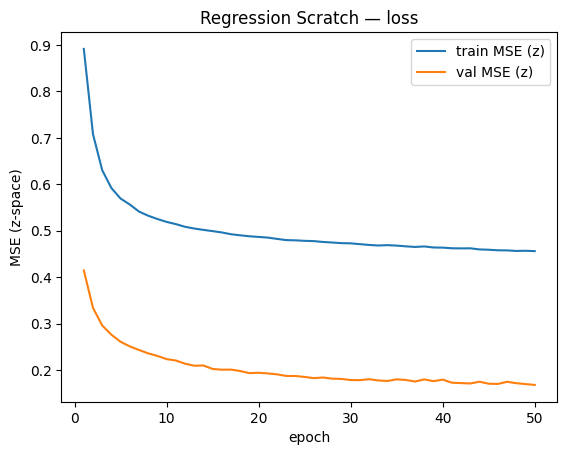

In [4]:
EPOCHS, BATCH = 50, 64
history = {"epoch": [], "train_loss_z": [], "val_loss_z": [], "val_rmse": []}
rng = np.random.default_rng(SEED)

def mse_z(a, b):
    return float(np.mean((a - b) ** 2))

for epoch in range(1, EPOCHS + 1):
    tot, n = 0.0, 0
    for xb, yb in batch_generator(train_ds, BATCH, True, rng):
        B = len(xb)
        Z1, A1, pred = model.forward(xb)
        tot += mse_z(pred, yb) * B; n += B
        # --- backward (mean MSE in z-space), dL/dpred = 2(pred-y)/B ---
        dpred = 2.0 * (pred - yb) / B
        dW2 = A1.T @ dpred; db2 = dpred.sum(axis=0)
        dA1 = dpred @ model.W2.T
        dZ1 = dA1 * (Z1 > 0)
        dW1 = xb.T @ dZ1; db1 = dZ1.sum(axis=0)
        model.adam_step({"W1": dW1, "b1": db1, "W2": dW2, "b2": db2})
    tr = tot / n
    pred_z = model.predict(test_ds.X)
    vl = mse_z(pred_z.reshape(-1, 1), test_ds.y)
    vr = float(np.sqrt(np.mean((z_to_raw(pred_z) - y_test) ** 2)))
    history["epoch"].append(epoch)
    history["train_loss_z"].append(tr)
    history["val_loss_z"].append(vl)
    history["val_rmse"].append(vr)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:02d} | train_MSE_z {tr:.4f} | val_MSE_z {vl:.4f} | val_RMSE_$ {vr:.0f}")

np.savez("weights/regression_scratch.npz", W1=model.W1, b1=model.b1, W2=model.W2, b2=model.b2,
         mean=scaler.mean_, scale=scaler.scale_, columns=np.array(REG_FEATURES),
         y_mean=np.array([Y_MEAN]), y_scale=np.array([Y_SCALE]))
pd.DataFrame(history).to_csv("weights/regression_scratch_history.csv", index=False)
print("saved: weights/regression_scratch.npz + scratch_history.csv")

plt.figure(); plt.plot(history["epoch"], history["train_loss_z"], label="train MSE (z)")
plt.plot(history["epoch"], history["val_loss_z"], label="val MSE (z)")
plt.xlabel("epoch"); plt.ylabel("MSE (z-space)"); plt.legend(); plt.title("Regression Scratch — loss"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights/regression_scratch.npz`, metrics in raw $

In [5]:
z = np.load("weights/regression_scratch.npz")
fresh = ScratchMLP(in_dim=len(REG_FEATURES), h=32, seed=0)
fresh.W1, fresh.b1, fresh.W2, fresh.b2 = z["W1"], z["b1"], z["W2"], z["b2"]
pred = z_to_raw(fresh.predict(test_ds.X))
test_mse = float(mean_squared_error(y_test, pred))
metrics = {
    "test_loss_MSE_raw": round(test_mse, 1),
    "rmse": round(float(np.sqrt(test_mse)), 1),
    "mae": round(float(mean_absolute_error(y_test, pred)), 1),
    "r2": round(float(r2_score(y_test, pred)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights/regression_scratch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
for i in range(5):
    print(f"  pred={pred[i]:.0f} true={y_test[i]:.0f}")

{
  "test_loss_MSE_raw": 113761654.3,
  "rmse": 10665.9,
  "mae": 6809.6,
  "r2": 0.7537,
  "n_test": 443,
  "seed": 42
}
  pred=68567 true=62450
  pred=38255 true=37235
  pred=65160 true=65492
  pred=43040 true=42618
  pred=42614 true=26997


## 7. Parity check — scratch vs PyTorch oracle (oracle must run first)

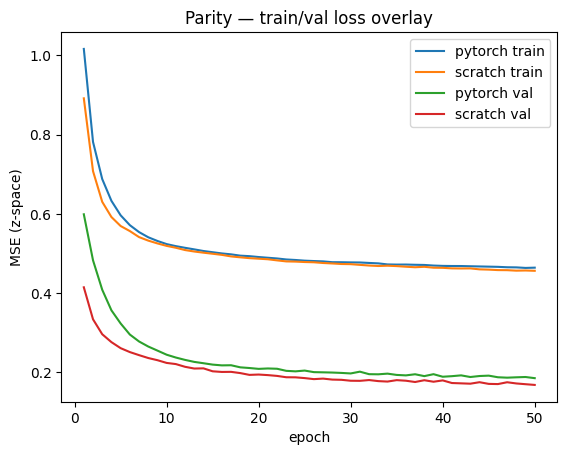

test_loss_MSE_raw 125307774.9 113761654.3  absΔ=11546120.60 relΔ=0.092
rmse                 11194.1     10665.9  absΔ=528.20 relΔ=0.047
mae                   7170.3      6809.6  absΔ=360.70 relΔ=0.050
r2                    0.7287      0.7537  absΔ=0.03 relΔ=0.034

PARITY: PASS (tolerances: RMSE relΔ<0.10, R²Δ<0.05; init RNGs differ by library, so exact match is not expected)


In [6]:
import os as _os
assert _os.path.exists("weights/regression_pytorch_history.csv"), "run regression_pytorch.ipynb first"
ph = pd.read_csv("weights/regression_pytorch_history.csv")
sh = pd.read_csv("weights/regression_scratch_history.csv")
plt.figure(); plt.plot(ph["epoch"], ph["train_loss_z"], label="pytorch train")
plt.plot(sh["epoch"], sh["train_loss_z"], label="scratch train")
plt.plot(ph["epoch"], ph["val_loss_z"], label="pytorch val")
plt.plot(sh["epoch"], sh["val_loss_z"], label="scratch val")
plt.xlabel("epoch"); plt.ylabel("MSE (z-space)"); plt.legend()
plt.title("Parity — train/val loss overlay"); plt.show()
pm = json.load(open("weights/regression_pytorch_test_metrics.json"))
sm = json.load(open("weights/regression_scratch_test_metrics.json"))
for k in ("test_loss_MSE_raw", "rmse", "mae", "r2"):
    d = abs(sm[k] - pm[k])
    rel = d / abs(pm[k]) if pm[k] != 0 else d
    print(f"{k:<16}{pm[k]:>12}{sm[k]:>12}  absΔ={d:.2f} relΔ={rel:.3f}")
rmse_ok = abs(sm["rmse"] - pm["rmse"]) / pm["rmse"] < 0.10
r2_ok = abs(sm["r2"] - pm["r2"]) < 0.05
print("\nPARITY:", "PASS" if (rmse_ok and r2_ok) else "FAIL",
      "(tolerances: RMSE relΔ<0.10, R²Δ<0.05; init RNGs differ by library, so exact match is not expected)")